In [1]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")

Using Colab cache for faster access to the 'fer2013' dataset.


Algorithm:
Custom Deep CNN with Data Augmentation and Class-Weighted Training

Model Architecture:
Multi-Layer Deep CNN (Trained from Scratch on FER2013)

In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

IMG_SIZE = 48
BATCH_SIZE = 128
EPOCHS = 60
LR = 1e-4
NUM_CLASSES = 7

train_dir = "/kaggle/input/fer2013/train"
val_dir   = "/kaggle/input/fer2013/test"

# -----------------------------
# DATA GENERATORS
# -----------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical"
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    class_mode="categorical",
    shuffle=False
)

# -----------------------------
# CLASS WEIGHTS (VERY IMPORTANT)
# -----------------------------
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))

# -----------------------------
# MODEL
# -----------------------------
model = Sequential([
    Conv2D(64, (3,3), activation="relu", padding="same", input_shape=(48,48,1)),
    BatchNormalization(),
    Conv2D(64, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    Conv2D(128, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(256, (3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(512, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(model.summary())

# -----------------------------
# CALLBACKS
# -----------------------------
callbacks = [
    EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6)
]

# -----------------------------
# TRAIN
# -----------------------------
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks
)

# -----------------------------
# SAVE
# -----------------------------
model.save("deep_emotion_model2.2.keras")

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,281,479 (20.15 MB)

 Trainable params: 5,279,175 (20.14 MB)

 Non-trainable params: 2,304 (9.00 KB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


None
Epoch 1/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 58s 214ms/step - accuracy: 0.1611 - loss: 3.0400 - val_accuracy: 0.0155 - val_loss: 19.9157 - learning_rate: 1.0000e-04
Epoch 2/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.2023 - loss: 2.5327 - val_accuracy: 0.0157 - val_loss: 18.7230 - learning_rate: 1.0000e-04
Epoch 3/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 184ms/step - accuracy: 0.2083 - loss: 2.3225 - val_accuracy: 0.1447 - val_loss: 2.5035 - learning_rate: 1.0000e-04
Epoch 4/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 42s 185ms/step - accuracy: 0.2233 - loss: 2.2674 - val_accuracy: 0.1857 - val_loss: 2.2507 - learning_rate: 1.0000e-04
Epoch 5/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.2301 - loss: 2.1465 - val_accuracy: 0.2634 - val_loss: 1.9635 - learning_rate: 1.0000e-04
Epoch 6/60
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.2545 - loss: 2.0764 - val_accuracy: 0.2214 - val_loss: 2.0824 - learning_rate: 1.0000e-04
Epoch 7/60
225/225 ━━━━━━━━━━━━━━━━━━━━

Phase 2 Fine Tunning

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print("Fine-tuning Phase 2...")

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # 🔥 lower LR
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

history_finetune = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

model.save("deep_emotion_model_finetuned.keras")

Fine-tuning Phase 2...
Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 222ms/step - accuracy: 0.5416 - loss: 1.2198 - val_accuracy: 0.5978 - val_loss: 1.0780 - learning_rate: 1.0000e-05
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step - accuracy: 0.5506 - loss: 1.1909 - val_accuracy: 0.6020 - val_loss: 1.0689 - learning_rate: 1.0000e-05
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 40s 179ms/step - accuracy: 0.5608 - loss: 1.1686 - val_accuracy: 0.6050 - val_loss: 1.0603 - learning_rate: 1.0000e-05
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 45s 199ms/step - accuracy: 0.5680 - loss: 1.1562 - val_accuracy: 0.6043 - val_loss: 1.0524 - learning_rate: 1.0000e-05
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step - accuracy: 0.5615 - loss: 1.1577 - val_accuracy: 0.6046 - val_loss: 1.0532 - learning_rate: 1.0000e-05
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 41s 181ms/step - accuracy: 0.5705 - loss: 1.1484 - val_accuracy: 0.6077 - val_loss: 1.0518 - learning_rate: 1.0000e-05
Epoch 7/20
225/225 ━━━━

Plot Training Curves

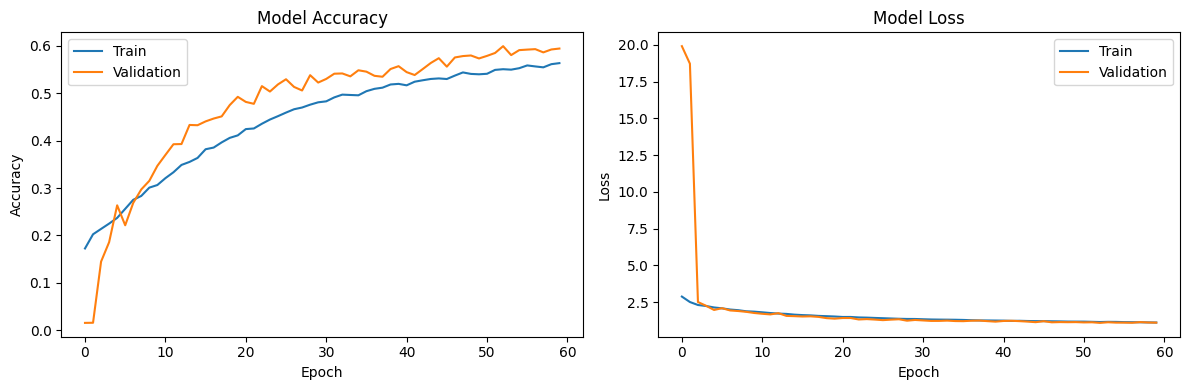

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Evaluate on Test Set

Found 7178 images belonging to 7 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step
Classification Report:

              precision    recall  f1-score   support

       angry       0.54      0.54      0.54       958
     disgust       0.47      0.47      0.47       111
        fear       0.51      0.29      0.37      1024
       happy       0.81      0.85      0.83      1774
     neutral       0.50      0.69      0.58      1233
         sad       0.50      0.44      0.47      1247
    surprise       0.73      0.76      0.75       831

    accuracy                           0.62      7178
   macro avg       0.58      0.58      0.57      7178
weighted avg       0.61      0.62      0.61      7178



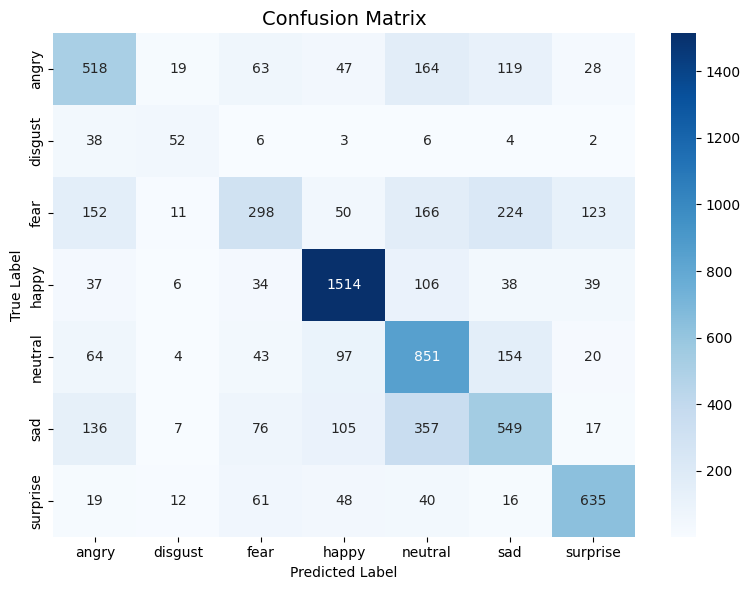

Per-Class Accuracy:
angry: 54.07%
disgust: 46.85%
fear: 29.10%
happy: 85.34%
neutral: 69.02%
sad: 44.03%
surprise: 76.41%


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load trained model
model = load_model('deep_emotion_model_finetuned.keras')

# Test data generator (MUST MATCH TRAINING)
test_datagen_eval = ImageDataGenerator(rescale=1./255)

test_gen = test_datagen_eval.flow_from_directory(
    '/kaggle/input/fer2013/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Predictions
y_pred_prob = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Per-Class Accuracy
print("Per-Class Accuracy:")
for i, cls in enumerate(class_names):
    cls_mask = (y_true == i)
    cls_acc = np.mean(y_pred[cls_mask] == y_true[cls_mask])
    print(f"{cls}: {cls_acc:.2%}")